In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import shutil
import time
import collections
import math
import pandas as pd
import copy

In [2]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
train_data = datasets.ImageFolder(root = '/content/drive/MyDrive/Airplane_Mini_Datasets_Collation/Train' , transform = transforms.ToTensor())


In [5]:


means = torch.zeros(3)
stds = torch.zeros(3)

for img, label in train_data:
    means += torch.mean(img, dim = (1,2))
    stds += torch.std(img, dim = (1,2))

means /= len(train_data)
stds /= len(train_data)

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')

Calculated means: tensor([0.4814, 0.5271, 0.5648])
Calculated stds: tensor([0.1980, 0.1922, 0.2178])


In [6]:
# set batch size to 32
batch_size = 32

transform_train = transforms.Compose([
    # Randomly crop the image to obtain an image with an area of 0.08 to 1 of
    # the original area and height-to-width ratio between 3/4 and 4/3. Then,
    # scale the image to create a new 224 x 224 image
    transforms.Resize((32,32)),
    transforms.RandomHorizontalFlip(),
    # Randomly change the brightness, contrast, and saturation
    transforms.ColorJitter(brightness=0.4,
                                       contrast=0.4,
                                       saturation=0.4),
    # Add random noise
    transforms.ToTensor(),
    # Standardize each channel of the image
    #transforms.Normalize([0.485, 0.456, 0.406],
    #                                 [0.229, 0.224, 0.225])
    transforms.Normalize([0.5570, 0.5570, 0.5570],[0.0620, 0.0620, 0.0620])
   ])

transform_test = transforms.Compose([
    transforms.Resize((32,32)),
    # Crop a 224 x 224 square area from the center of the image
    #torchvision.transforms.CenterCrop(32),
    transforms.ToTensor(),
    #transforms.Normalize([0.485, 0.456, 0.406],
    #                                 [0.229, 0.224, 0.225])
    transforms.Normalize([0.5570, 0.5570, 0.5570],[0.0620, 0.0620, 0.0620])
   ])

In [7]:


data_dir = '/content/drive/MyDrive/Airplane_Mini_Datasets_Collation'

# Load datasets
train_ds, train_valid_ds = [datasets.ImageFolder(
    os.path.join(data_dir, folder),
    transform=transform_train) for folder in ['Train', 'Validation']]

valid_ds, test_ds = [datasets.ImageFolder(
    os.path.join(data_dir, folder),
    transform=transform_test) for folder in ['Validation', 'Test']]






In [8]:
train_iter, train_valid_iter = [torch.utils.data.DataLoader(
    dataset, batch_size, shuffle=True, drop_last=True)
    for dataset in (train_ds, train_valid_ds)]

valid_iter = torch.utils.data.DataLoader(valid_ds, batch_size, shuffle=False,
                                         drop_last=True)

test_iter = torch.utils.data.DataLoader(test_ds, batch_size, shuffle=False,
                                        drop_last=False)

In [9]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize = True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize = (15, 15))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        label = classes[labels[i]]
        ax.set_title(label)
        ax.axis('off')

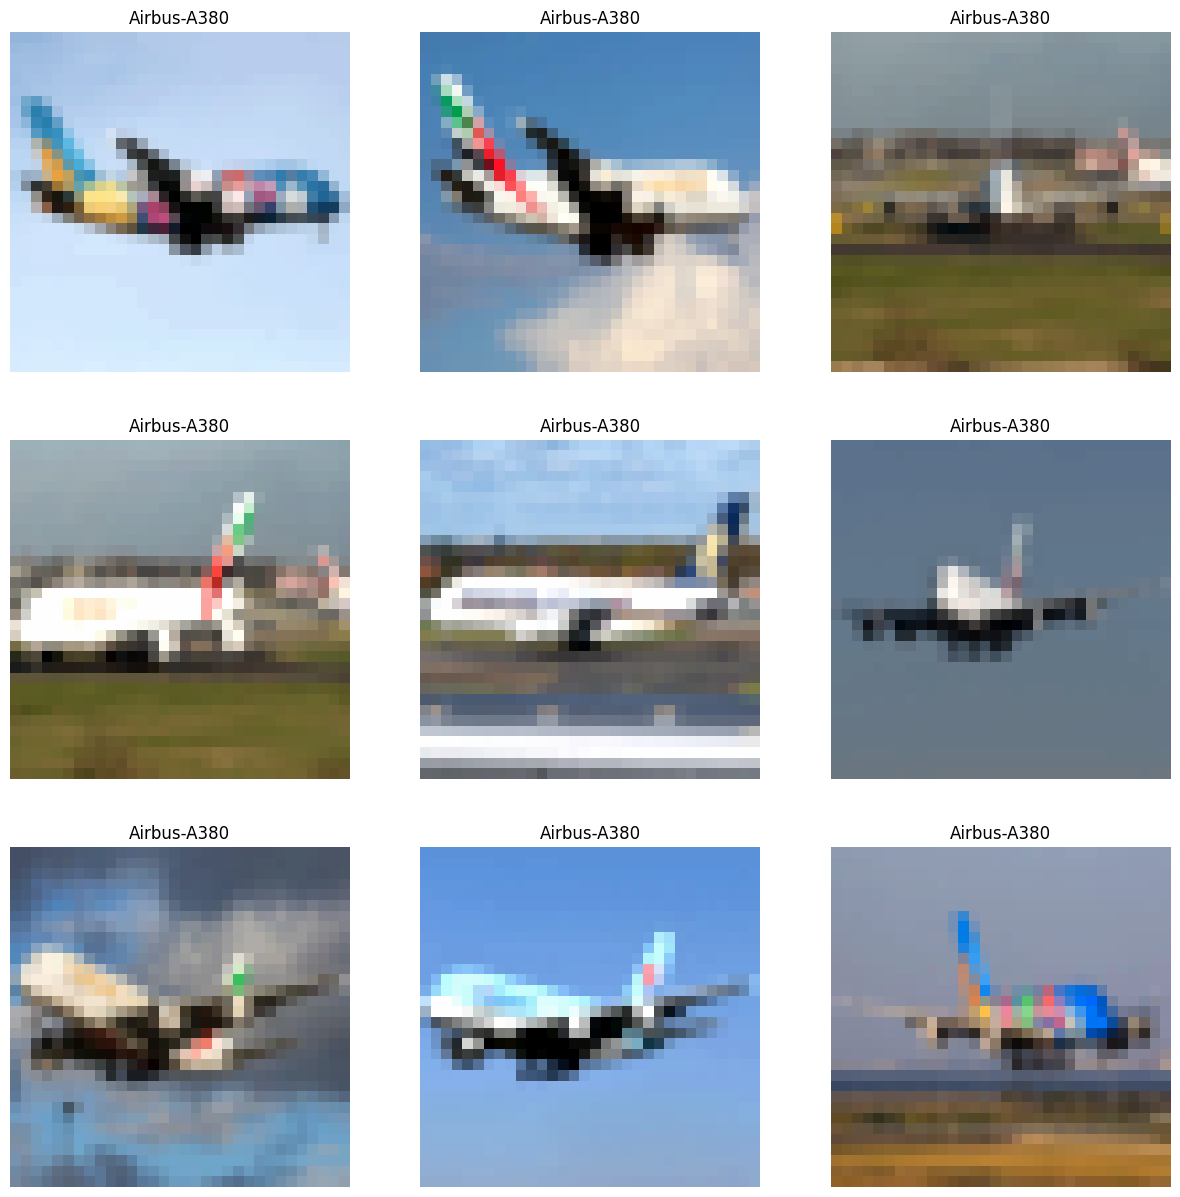

In [10]:
N_IMAGES = 10
j=int(len(train_ds)/2) - int(N_IMAGES/2)

images, labels = zip(*[(image, label) for image, label in
                           [train_ds[i+j] for i in range(N_IMAGES)]])

classes = train_ds.classes

plot_images(images, labels, classes)

In [51]:
class AlexNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1),  # in_channels, out_channels, kernel_size, stride, padding
            nn.MaxPool2d(2),  # kernel_size
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 192, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(inplace=True),
            nn.Conv2d(192, 384, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256 * 2 * 2, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, output_dim),
        )

    def forward(self, x):
        x = self.features(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

In [52]:
OUTPUT_DIM = 13

model = AlexNet(OUTPUT_DIM)

def initialize_parameters(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight.data, nonlinearity='relu')
        nn.init.constant_(m.bias.data, 0)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight.data, gain=nn.init.calculate_gain('relu'))
        nn.init.constant_(m.bias.data, 0)

model.apply(initialize_parameters)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=1024, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, in

In [53]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 23,284,557 trainable parameters


In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

CHOSE_LR = 1e-3

optimizer = optim.Adam(model.parameters(), lr=CHOSE_LR)

In [55]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [56]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred, _ = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [57]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [58]:
def get_predictions(model, iterator, device):

    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred, _ = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

Epochs:   0%|          | 0/33 [00:00<?, ?it/s]

Training:   0%|          | 0/112 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Epochs:   3%|▎         | 1/33 [00:28<15:26, 28.96s/it]

Epoch: 01 | Epoch Time: 0m 28s
	Train Loss: 5.119 | Train Acc: 8.01%
	 Val. Loss: 2.563 |  Val. Acc: 7.81%


...

Epoch: 32 | Epoch Time: 0m 30s
	Train Loss: 1.434 | Train Acc: 49.33%
	 Val. Loss: 2.233 |  Val. Acc: 35.94%


Training:   0%|          | 0/112 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Epochs: 100%|██████████| 33/33 [16:04<00:00, 29.23s/it]

Epoch: 33 | Epoch Time: 0m 28s
	Train Loss: 1.415 | Train Acc: 48.83%
	 Val. Loss: 2.166 |  Val. Acc: 30.73%


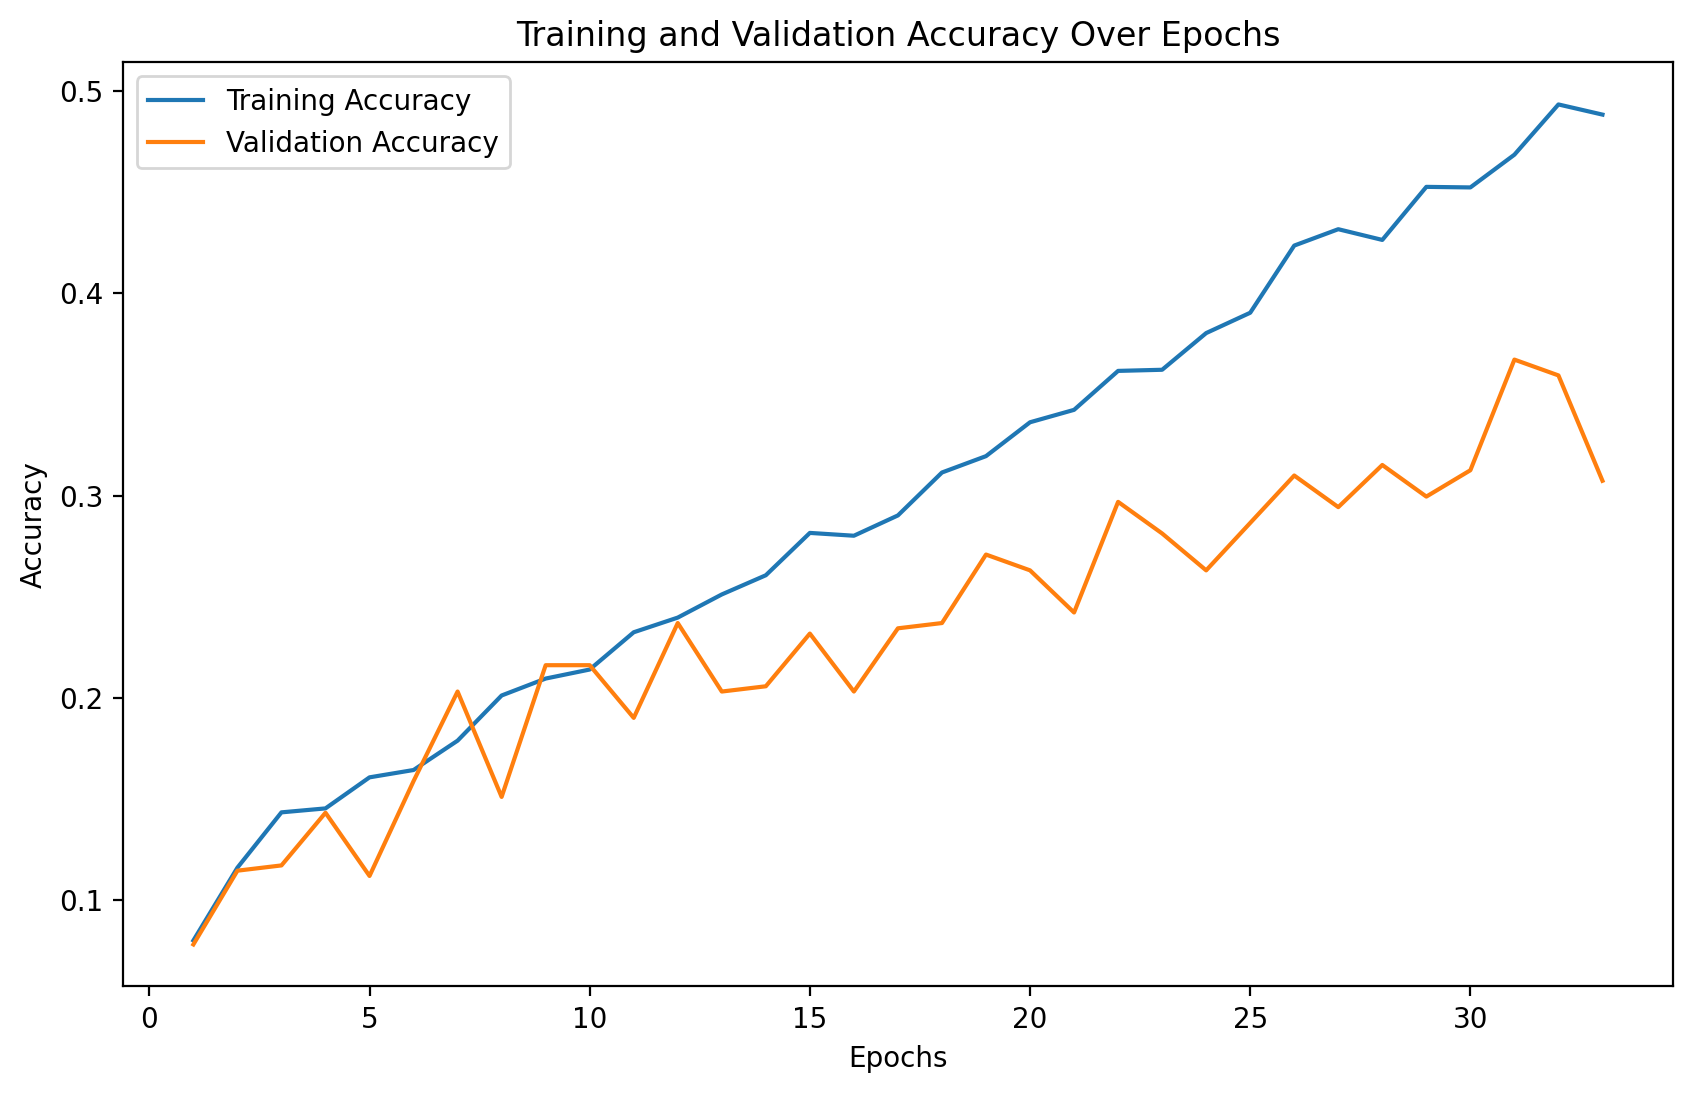

In [59]:
import time
import matplotlib.pyplot as plt
from tqdm import trange
import torch

EPOCHS = 33  # You may need to run longer to get better results. Lab example is for demo only

# keeping-track-of-losses and accuracies
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

best_valid_loss = float('inf')

for epoch in trange(EPOCHS, desc="Epochs"):
    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iter, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iter, criterion, device)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

# Plotting training and validation accuracies
plt.figure(figsize=(10, 6))
epochs_range = range(1, EPOCHS + 1)

plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, valid_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.legend()
plt.show()


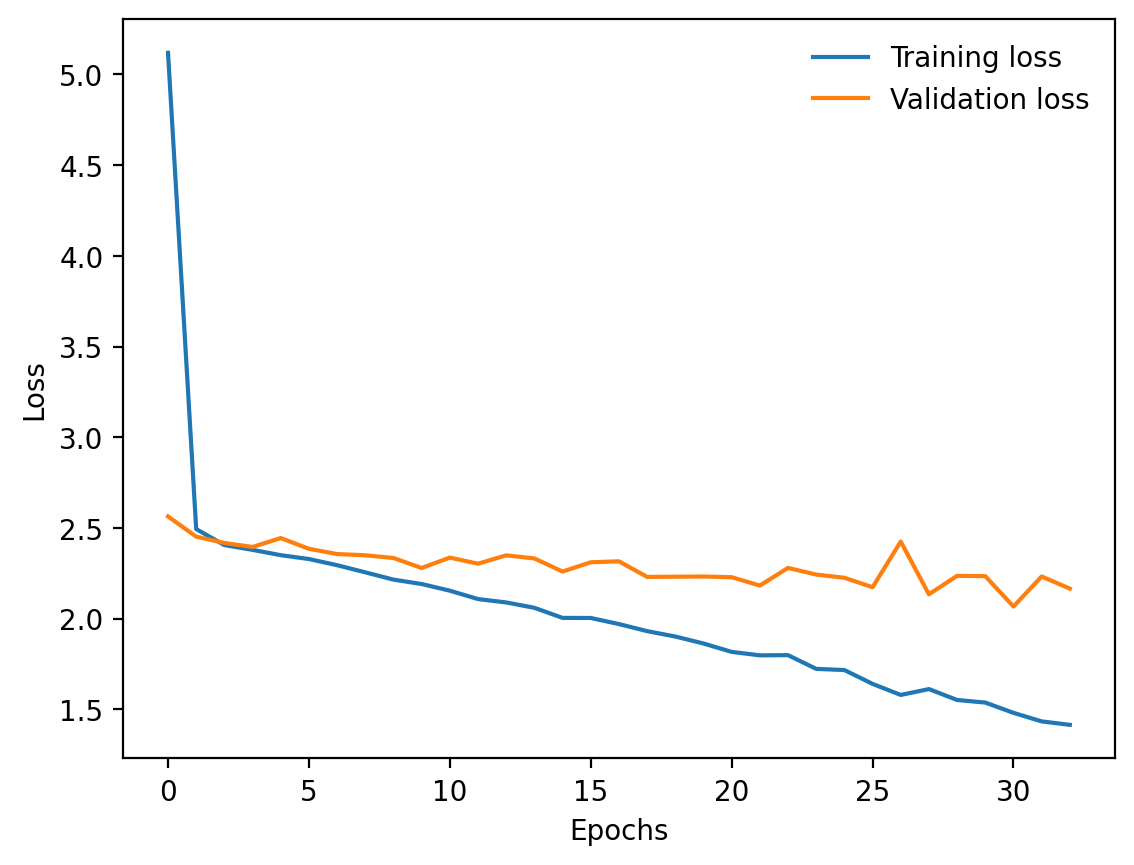

In [60]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(frameon=False)

In [61]:
model.load_state_dict(torch.load('best-model.pt'))

<All keys matched successfully>

In [62]:
images, labels, probs = get_predictions(model, test_iter, device)

In [63]:
test =('/content/drive/MyDrive/Airplane_Mini_Datasets_Collation/Test')


In [64]:
def get_predictions(model, iterator, device):
    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)

            y_pred, _ = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

# Now, call get_predictions with the 'device' argument
test_images, test_labels, probs = get_predictions(model, test_iter, device)


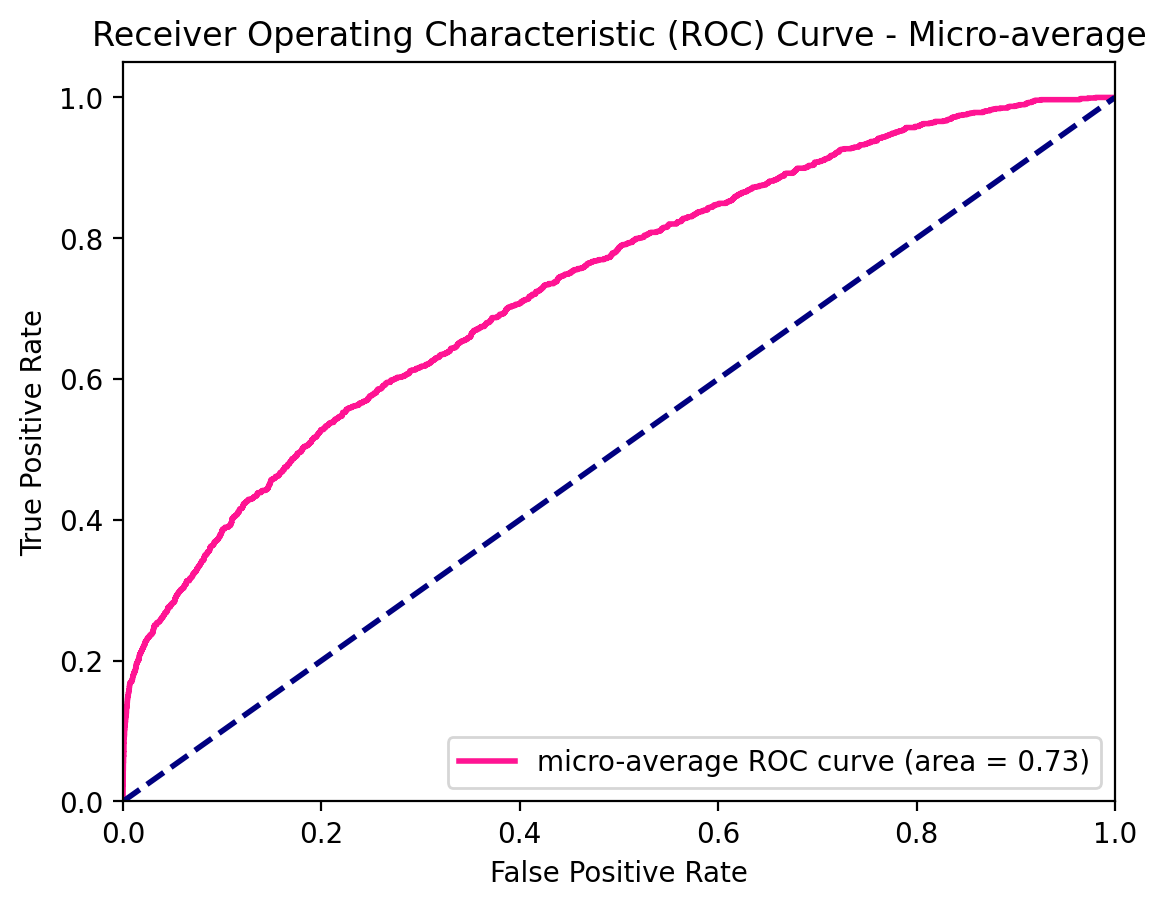

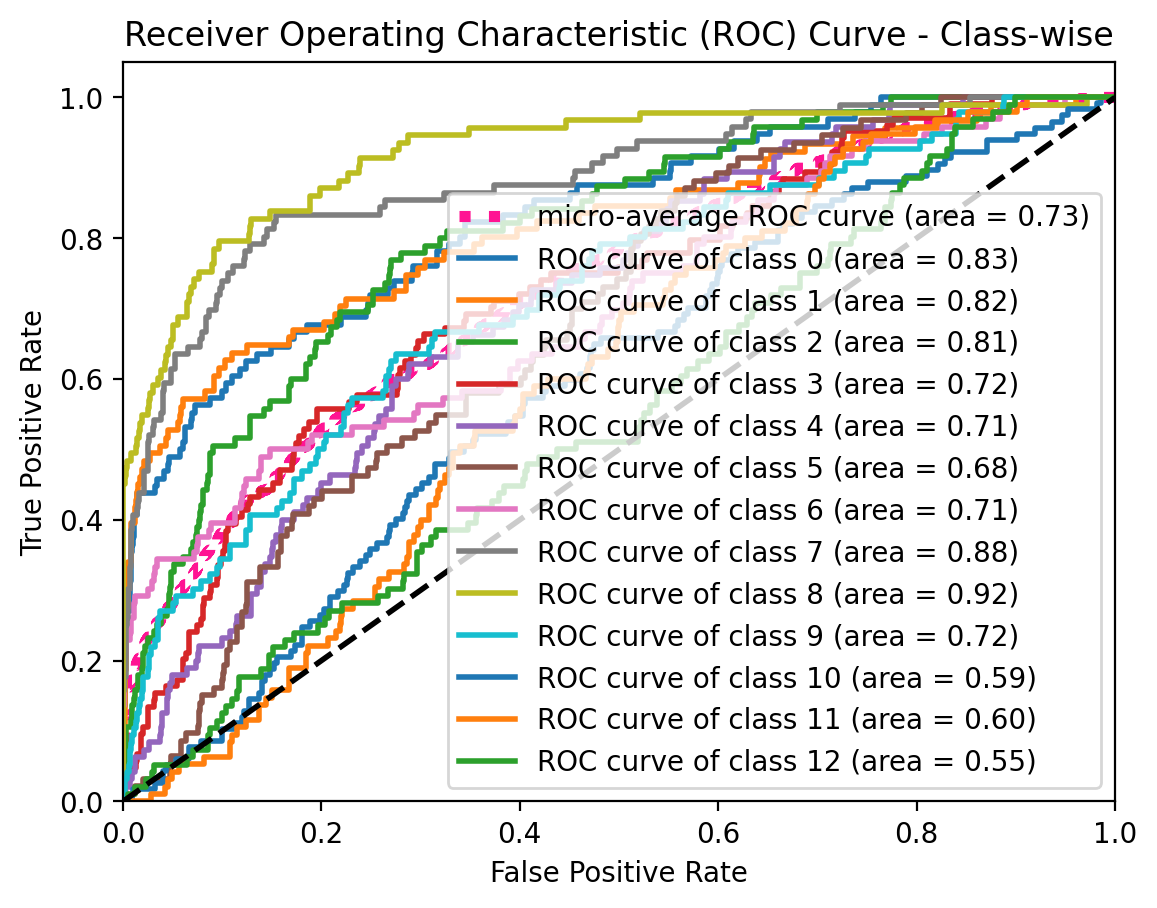

In [65]:
# Assuming 'probs' contains the predicted probabilities (already computed)
# 'test_labels' holds the true labels for the test dataset

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the labels
n_classes = 13  # Replace with the actual number of classes in your dataset
test_labels_binarized = label_binarize(test_labels.numpy(), classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_binarized[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(test_labels_binarized.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot micro-average ROC curve
plt.figure()
lw = 2
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', lw=lw,
         label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Micro-average')
plt.legend(loc="lower right")
plt.show()

# Plot ROC curve for each class
plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=lw, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Class-wise')
plt.legend(loc="lower right")
plt.show()


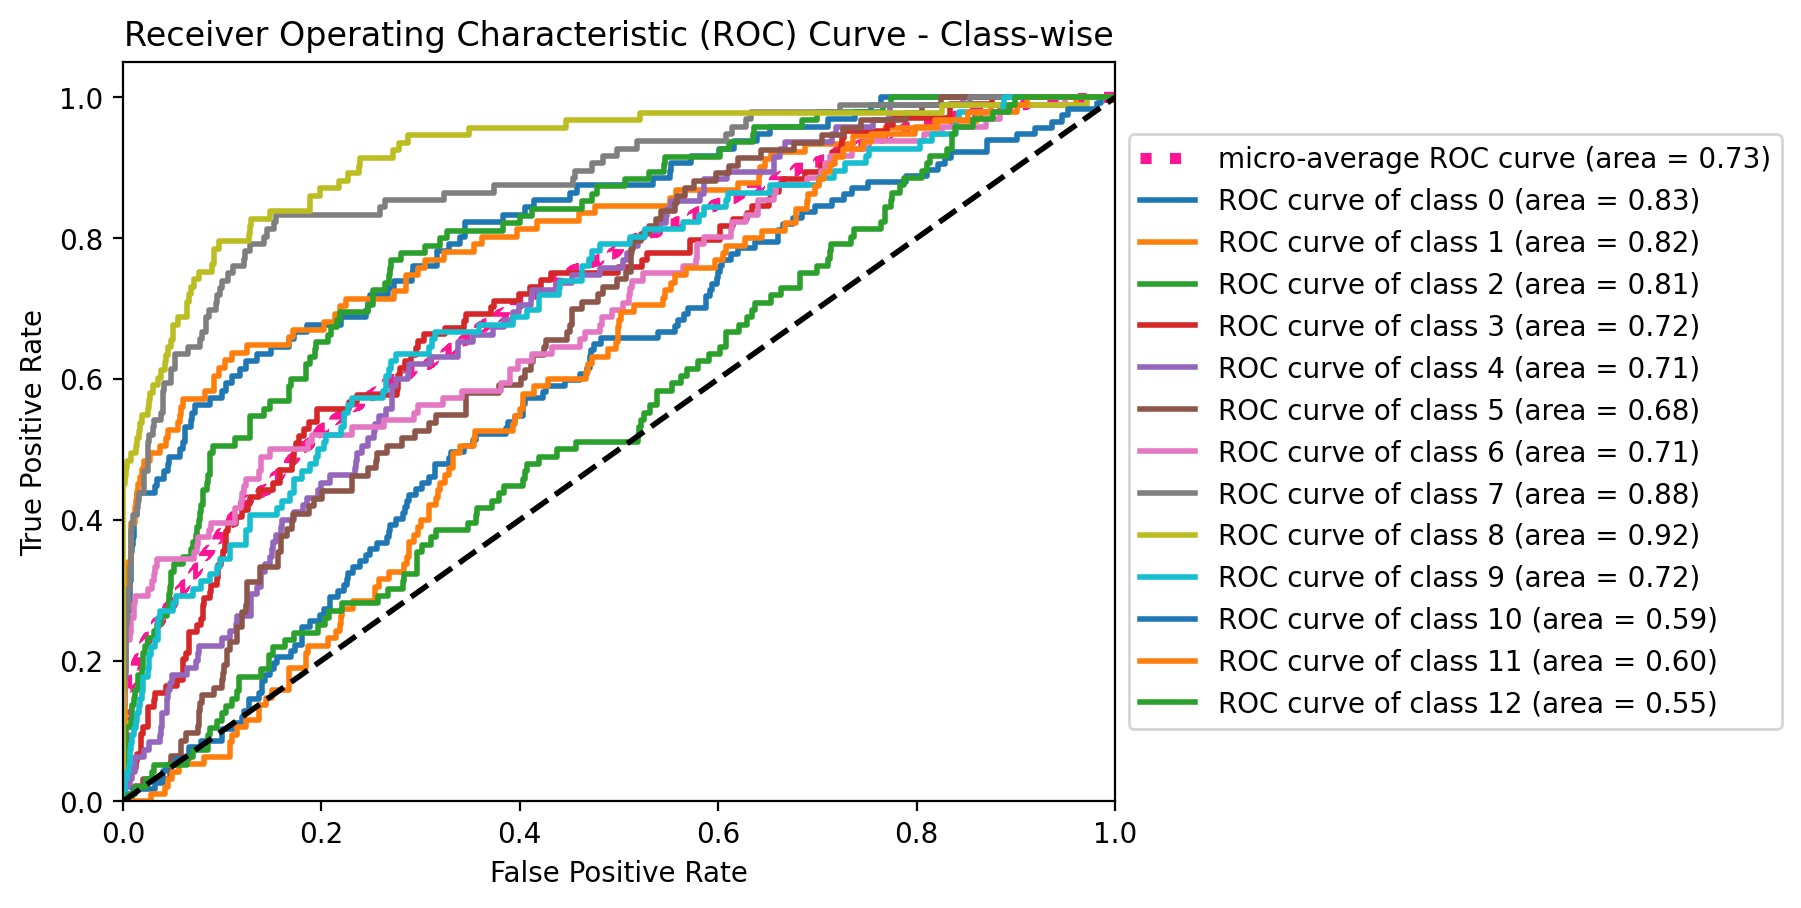

In [66]:
# Plot ROC curve for each class with legend outside the plot
plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=lw, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Class-wise')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


[[35  9  9 25  4  5  0  2  0  4  0  1  2]
 [ 1 51 18  4  0  4  0  5  0  2  1  4  1]
 [ 0  2 60  7  1  5  0 12  1  1  4  1  1]
 [10  8 15 23  9  7  1  1  1 15  3  9  2]
 [ 3  3 18 16 24  6  1  4  0  6  5  7  2]
 [ 1  1 13  5 20 14  0  5  0  2  4 15 13]
 [ 2  0 19  2  3  2 27 16  2  1  6  9  7]
 [ 1  1  3  2  2  6  1 72  0  2  1  4  1]
 [ 0  3 10  0  0  4  1 24 45  2  1  1  2]
 [ 5  4 26  6 12  6  3  2  0 24  0  7  1]
 [ 3 13 28  7  9 10  1 21  3  8  3  7  4]
 [ 3  2 20  4 24 19  3  7  0  2  4  3  4]
 [ 5  6 14 12 16 13  1  5  1  6  2 11  4]]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


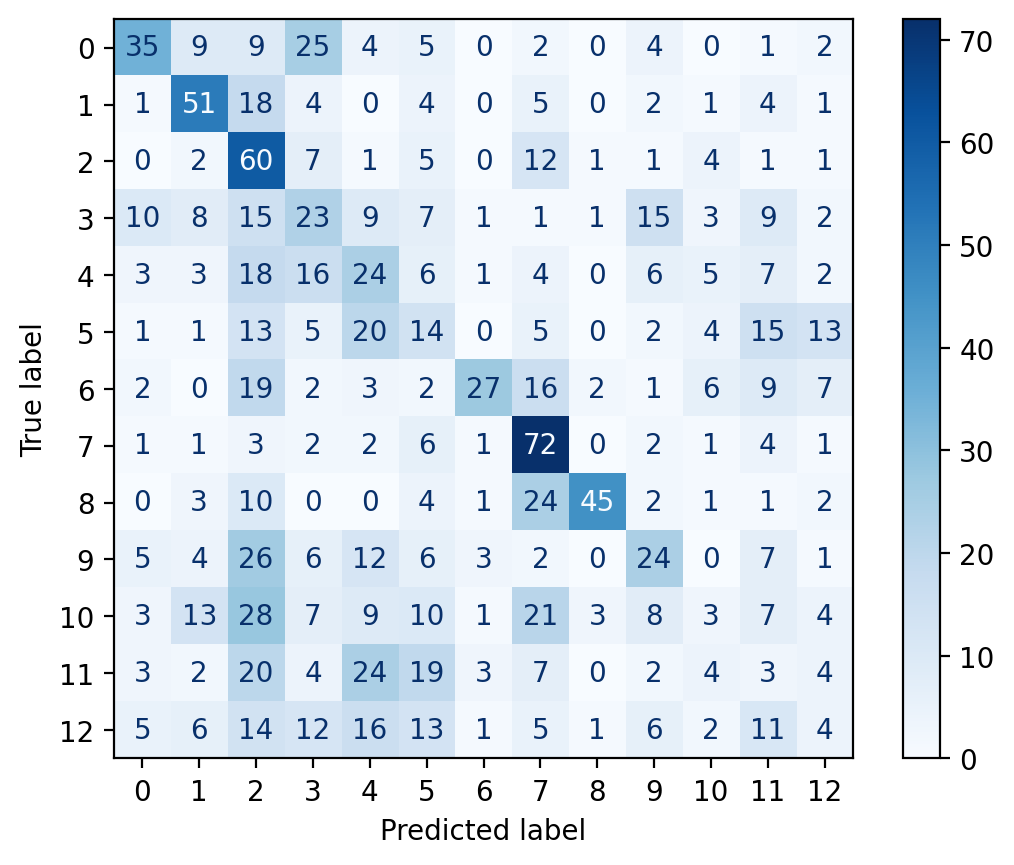

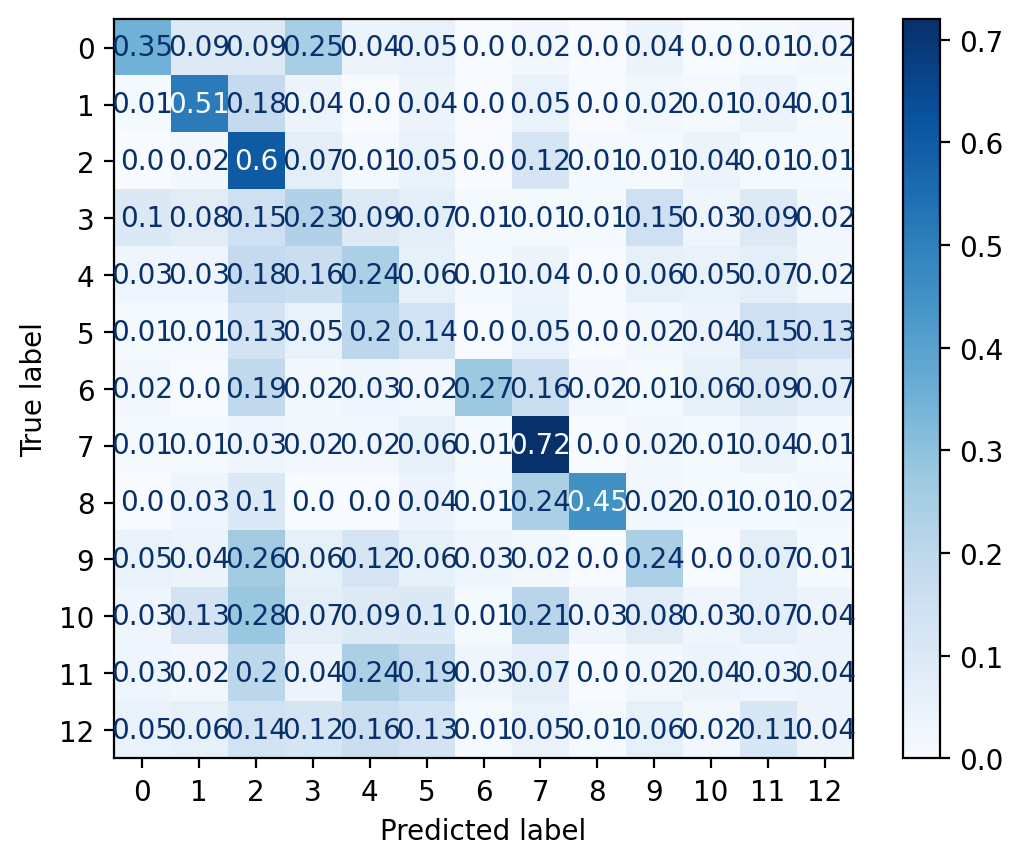

In [67]:
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
from matplotlib.colors import Normalize
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming 'probs' contains the predicted probabilities (already computed)
pred_class = torch.argmax(probs, axis=1).numpy()  # Convert predicted probabilities to class labels
true_class = labels.numpy()  # Convert true labels to numpy array

cm = confusion_matrix(true_class, pred_class)
class_names = unique_labels(true_class, pred_class)
print(cm)
print(class_names)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

# Normalized confusion matrix
C = cm
divisor = np.zeros((n_classes, n_classes))  # Update 'n_classes' to the number of classes in your dataset
divisor[:] = 100  # Set divisor values
cm_normalised = np.divide(cm, divisor)
cm_normalised = np.round(cm_normalised, 2)
disp = ConfusionMatrixDisplay(cm_normalised, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='')


In [68]:
test_data = datasets.ImageFolder(root='/content/drive/MyDrive/Airplane_Mini_Datasets_Collation/Test', transform=transforms.ToTensor())
class_names = test_data.classes
print(class_names)

['Airbus-A220', 'Airbus-A300', 'Airbus-A310', 'Airbus-A320', 'Airbus-A330', 'Airbus-A350', 'Airbus-A380', 'Boeing-B707', 'Boeing-B727', 'Boeing-B737', 'Boeing-B767', 'Boeing-B777', 'Boeing-B787']


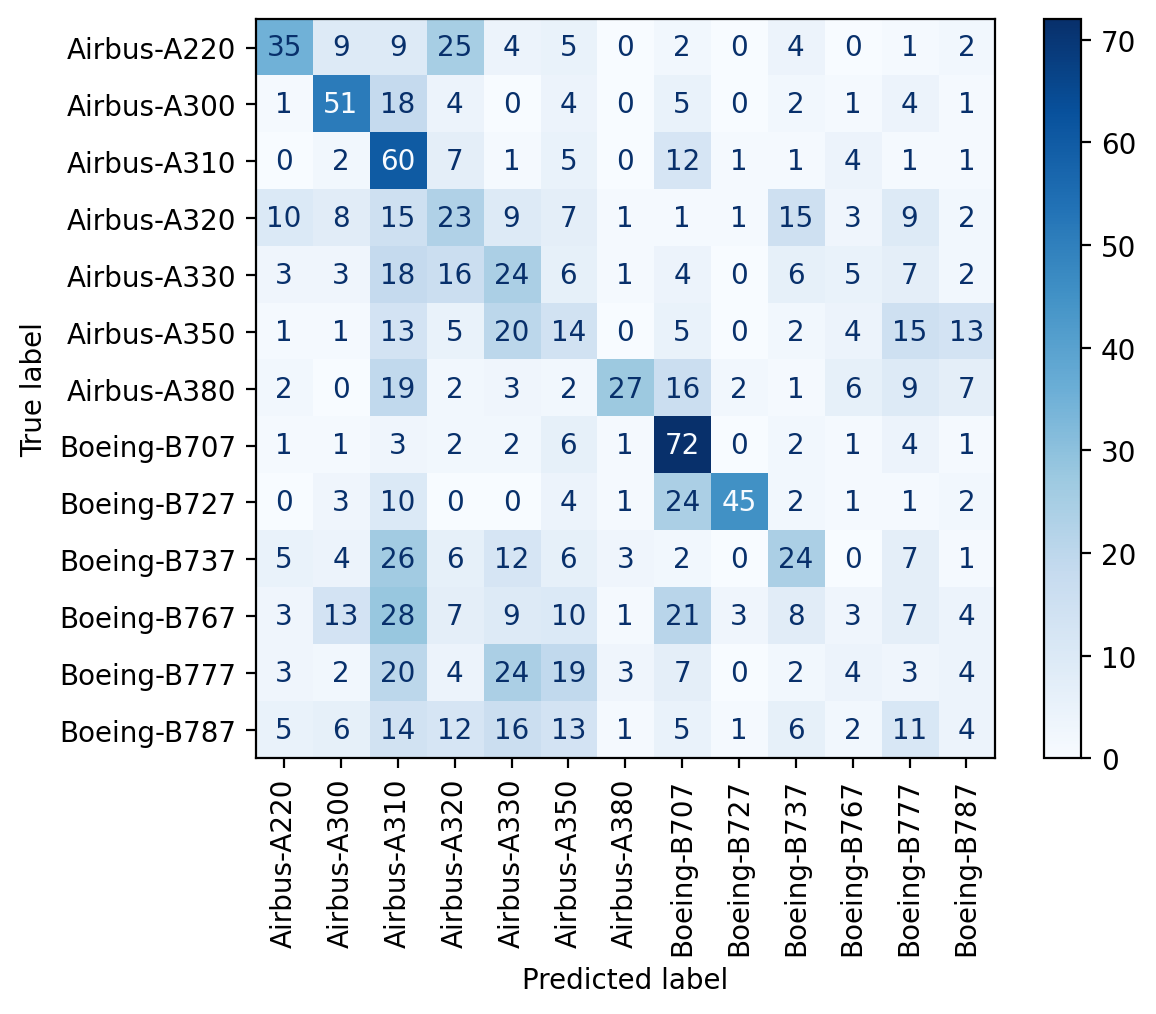

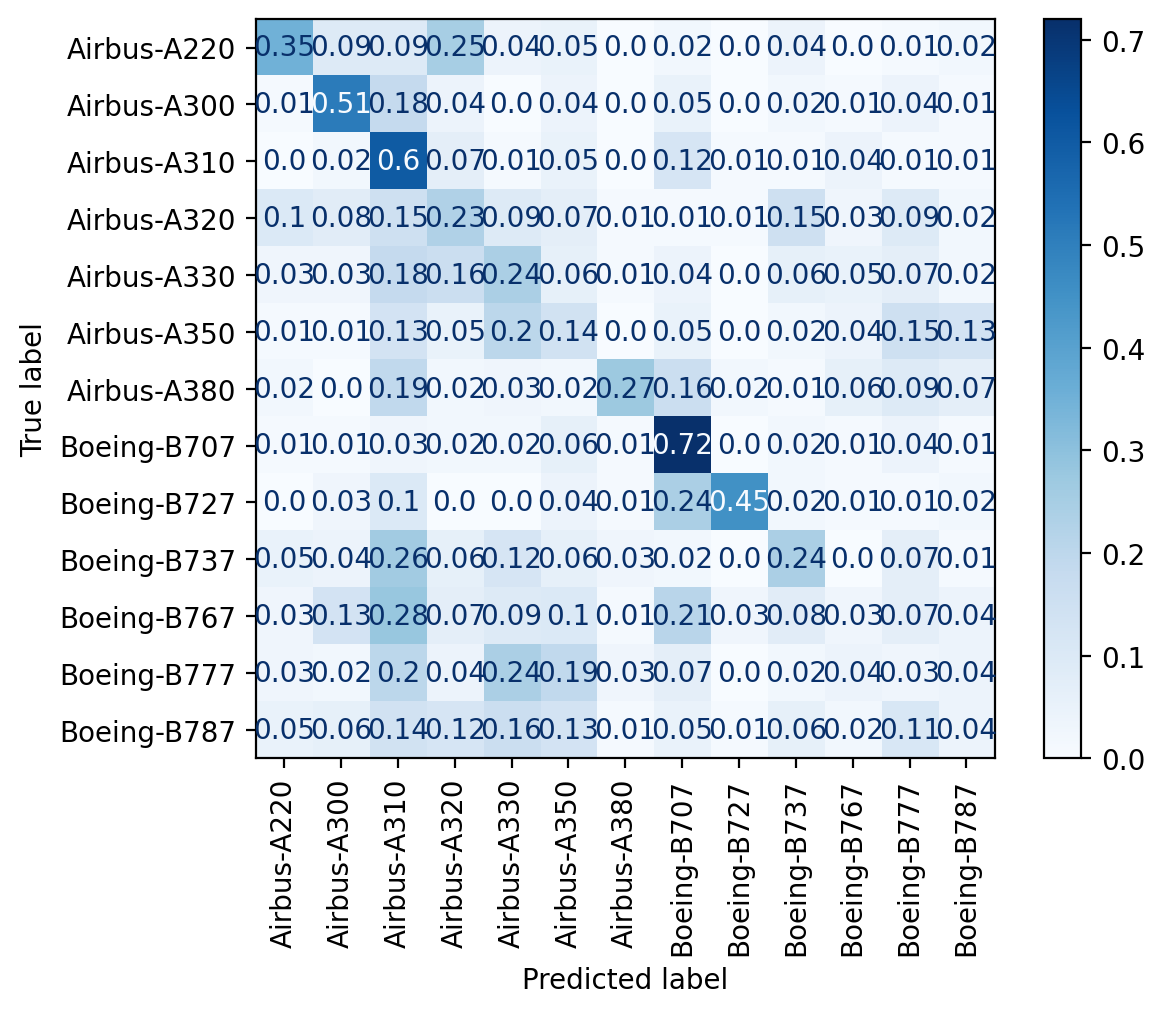

In [69]:
class_names = ['Airbus-A220', 'Airbus-A300', 'Airbus-A310', 'Airbus-A320', 'Airbus-A330', 'Airbus-A350', 'Airbus-A380', 'Boeing-B707', 'Boeing-B727', 'Boeing-B737', 'Boeing-B767', 'Boeing-B777', 'Boeing-B787']

# Plot confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues,xticks_rotation='vertical')

# Normalized confusion matrix
cm_normalised = np.divide(cm, divisor)
cm_normalised = np.round(cm_normalised, 2)
disp = ConfusionMatrixDisplay(cm_normalised, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='',xticks_rotation='vertical')


In [70]:
class_names = ['Airbus-A220', 'Airbus-A300', 'Airbus-A310', 'Airbus-A320', 'Airbus-A330', 'Airbus-A350', 'Airbus-A380', 'Boeing-B707', 'Boeing-B727', 'Boeing-B737', 'Boeing-B767', 'Boeing-B777', 'Boeing-B787']  # Replace with your class names

for i in range(len(class_names)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    tn = np.sum(cm) - (tp + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    print(f'Class: {class_names[i]}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1_score:.4f}')
    print(f'Specificity: {specificity:.4f}\n')



Class: Airbus-A220
Precision: 0.5072
Recall: 0.3646
F1-score: 0.4242
Specificity: 0.9709

Class: Airbus-A300
Precision: 0.4951
Recall: 0.5604
F1-score: 0.5258
Specificity: 0.9556

Class: Airbus-A310
Precision: 0.2372
Recall: 0.6316
F1-score: 0.3448
Specificity: 0.8348

Class: Airbus-A320
Precision: 0.2035
Recall: 0.2212
F1-score: 0.2120
Specificity: 0.9223

Class: Airbus-A330
Precision: 0.1935
Recall: 0.2526
F1-score: 0.2192
Specificity: 0.9144

Class: Airbus-A350
Precision: 0.1386
Recall: 0.1505
F1-score: 0.1443
Specificity: 0.9256

Class: Airbus-A380
Precision: 0.6923
Recall: 0.2812
F1-score: 0.4000
Specificity: 0.9897

Class: Boeing-B707
Precision: 0.4091
Recall: 0.7500
F1-score: 0.5294
Specificity: 0.9109

Class: Boeing-B727
Precision: 0.8491
Recall: 0.4839
F1-score: 0.6164
Specificity: 0.9932

Class: Boeing-B737
Precision: 0.3200
Recall: 0.2500
F1-score: 0.2807
Specificity: 0.9563

Class: Boeing-B767
Precision: 0.0882
Recall: 0.0256
F1-score: 0.0397
Specificity: 0.9729

Class: Boe

In [71]:
# Compute overall metrics from the confusion matrix
tp = np.diag(cm)
fp = np.sum(cm, axis=0) - tp
fn = np.sum(cm, axis=1) - tp
tn = np.sum(cm) - (tp + fp + fn)

# Calculate overall metrics
precision = np.sum(tp / (tp + fp)) / len(tp)
recall = np.sum(tp / (tp + fn)) / len(tp)
f1_score = np.sum(2 * tp / (2 * tp + fp + fn)) / len(tp)
specificity = np.sum(tn / (tn + fp)) / len(tp)

print(f'Overall Precision: {precision:.4f}')
print(f'Overall Recall: {recall:.4f}')
print(f'Overall F1-score: {f1_score:.4f}')
print(f'Overall Specificity: {specificity:.4f}')


Overall Precision: 0.3279
Overall Recall: 0.3111
Overall F1-score: 0.2945
Overall Specificity: 0.9421


In [72]:
model.load_state_dict(torch.load('best-model.pt'))
model.eval()

total_correct = 0
total_samples = 0

with torch.no_grad():
    for x, y in test_iter:
        x = x.to(device)
        y = y.to(device)

        # Forward pass
        y_pred, _ = model(x)

        # Calculate accuracy
        _, predicted_labels = torch.max(y_pred, 1)
        correct = (predicted_labels == y).sum().item()
        total_correct += correct
        total_samples += y.size(0)

# Compute overall accuracy
testing_accuracy = total_correct / total_samples

print(f'Testing Accuracy: {testing_accuracy * 100:.2f}%')


Testing Accuracy: 30.48%


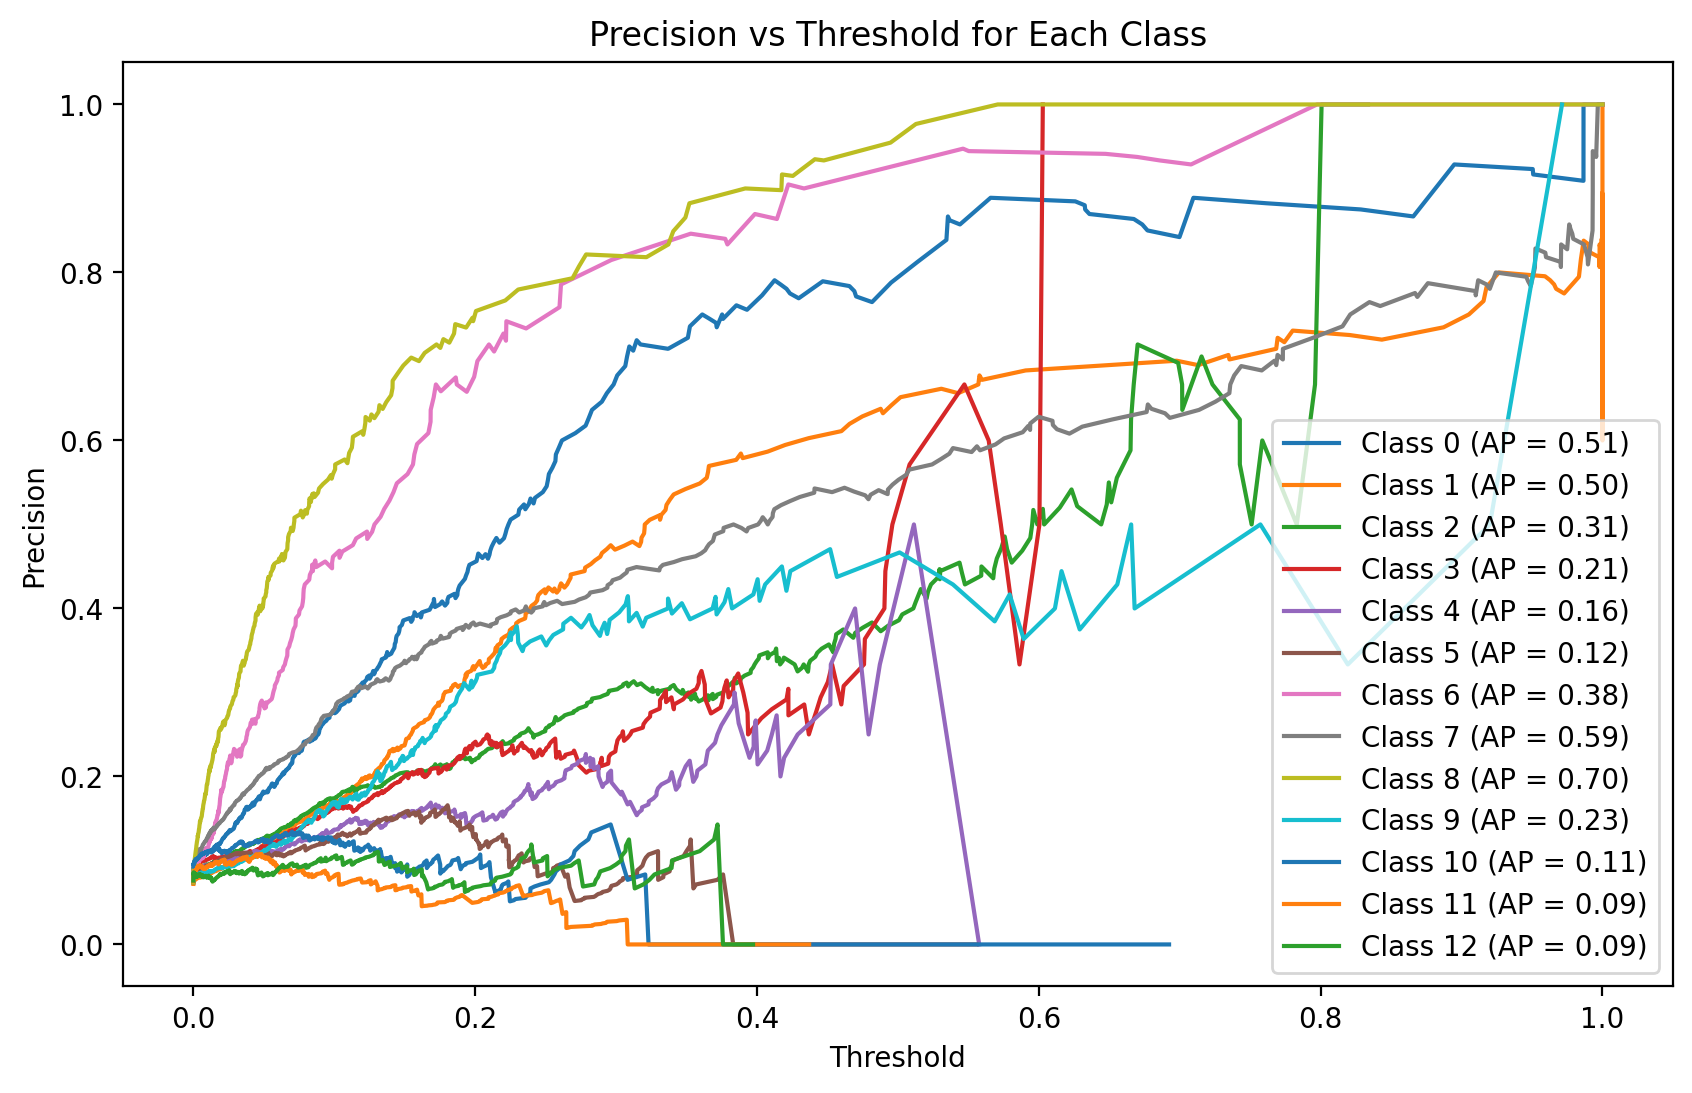

In [73]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Assuming 'probs' contains the predicted probabilities (already computed)
# 'test_labels' holds the true labels for the test dataset

# Binarize the labels
n_classes = 13
test_labels_binarized = label_binarize(test_labels.numpy(), classes=np.arange(n_classes))

# Compute precision-recall curve for each class
precision = dict()
recall = dict()
average_precision = dict()
thresholds = dict()

for i in range(n_classes):
    precision[i], recall[i], thresholds[i] = precision_recall_curve(test_labels_binarized[:, i], probs[:, i])
    average_precision[i] = average_precision_score(test_labels_binarized[:, i], probs[:, i])

# Plot precision against the threshold for each class
plt.figure(figsize=(10, 6))

for i in range(n_classes):
    plt.plot(thresholds[i], precision[i][:-1], label=f'Class {i} (AP = {average_precision[i]:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.title('Precision vs Threshold for Each Class')
plt.legend()
plt.show()


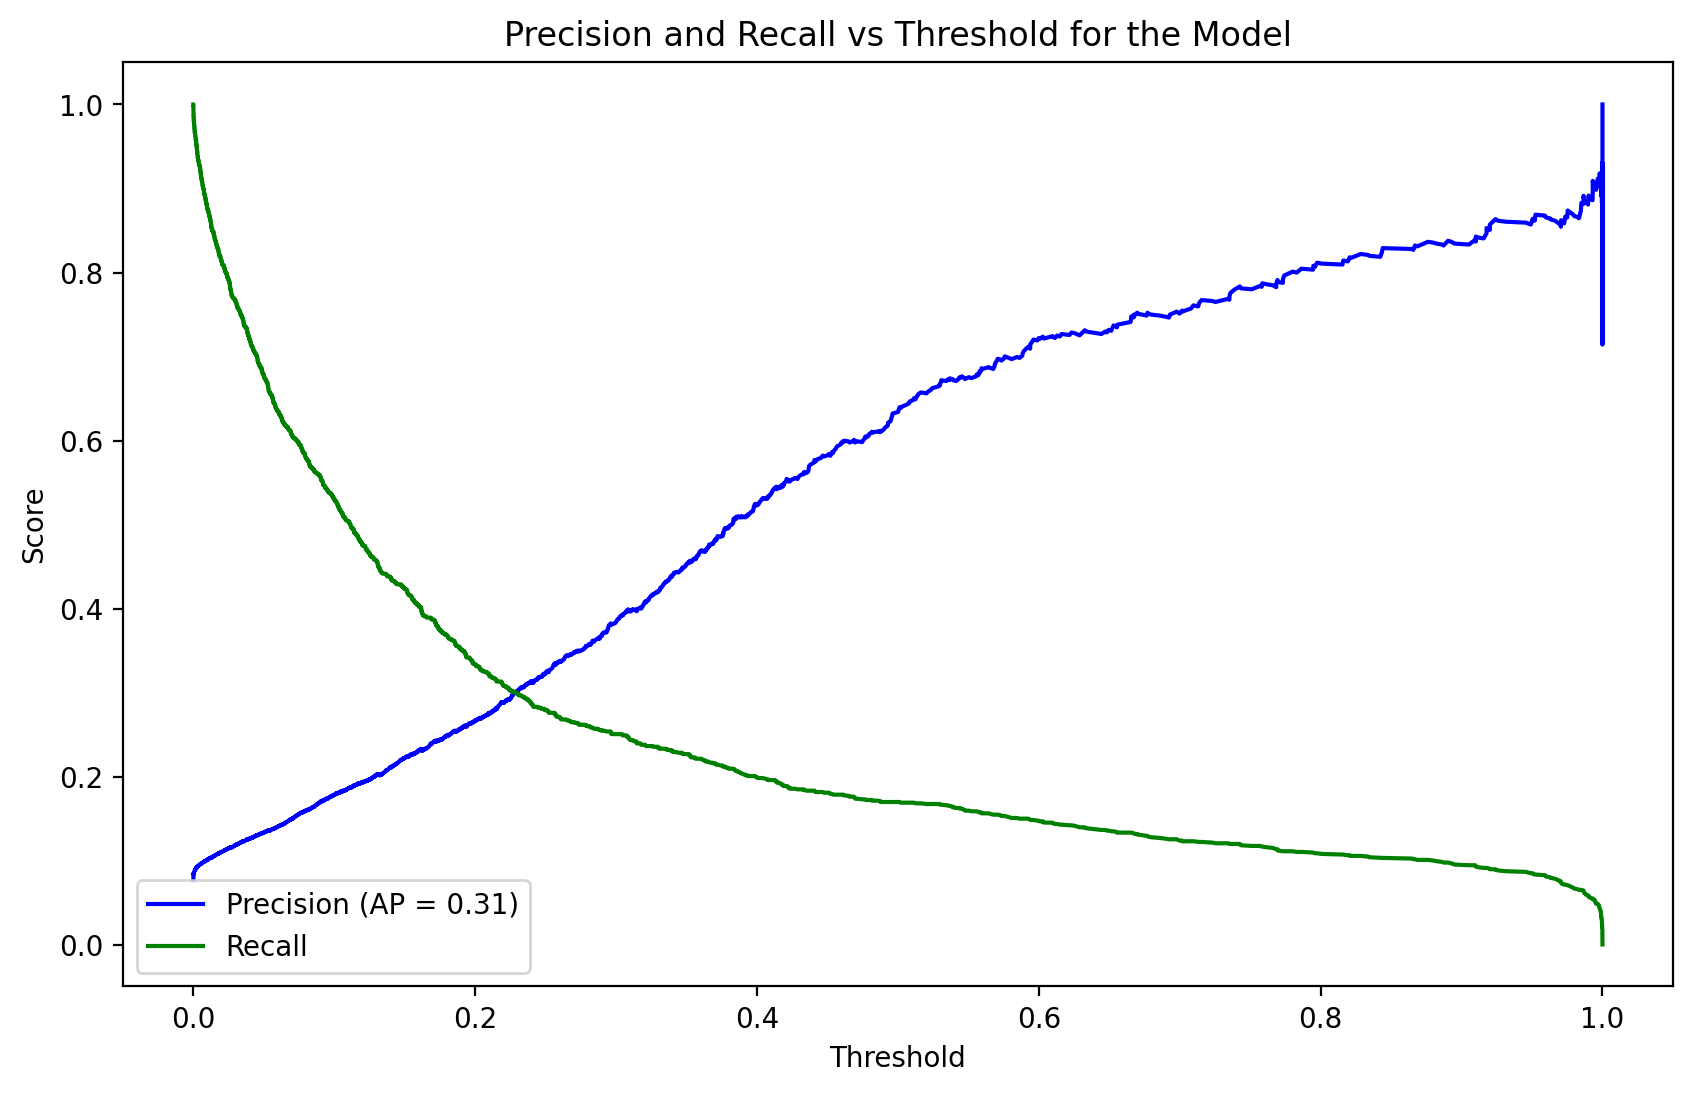

In [74]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Assuming 'probs' contains the predicted probabilities (already computed)
# 'test_labels' holds the true labels for the test dataset

# Binarize the labels
n_classes = 13
test_labels_binarized = label_binarize(test_labels.numpy(), classes=np.arange(n_classes))

# Compute precision-recall curve for the model overall
precision, recall, thresholds = precision_recall_curve(test_labels_binarized.ravel(), probs.ravel())
average_precision = average_precision_score(test_labels_binarized, probs, average="micro")

# Plot precision and recall against the threshold
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label=f'Precision (AP = {average_precision:.2f})', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold for the Model')
plt.legend()
plt.show()
